## Exploratory Data Analysis

Understand the load and weather series before building forecasting features:
missing data, seasonality (daily/weekly/annual), the load–temperature
relationship, trend, stationarity, and autocorrelation structure. The
findings here motivate the feature choices in `configs/default.yaml`
(`load_lags_hours`, `rolling_windows_hours`, `use_temperature`, ...).


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

project_root = Path.cwd()
while not (project_root / "src").is_dir() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.config import load_config
from src.data import load_all_tasks

sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option("display.max_columns", 30)


## 1. Load the data

In [2]:
config = load_config("configs/default.yaml")
data_dir = config["data"]["raw_dir"]
df = load_all_tasks(data_dir)
df.head()


  Loaded Task  1:  85440 rows  (2001-01-01 01:00:00 to 2010-10-01 00:00:00)
  Loaded Task  2:    744 rows  (2010-10-01 01:00:00 to 2010-11-01 00:00:00)
  Loaded Task  3:    720 rows  (2010-11-01 01:00:00 to 2010-12-01 00:00:00)
  Loaded Task  4:    744 rows  (2010-12-01 01:00:00 to 2011-01-01 00:00:00)
  Loaded Task  5:    744 rows  (2011-01-01 01:00:00 to 2011-02-01 00:00:00)
  Loaded Task  6:    672 rows  (2011-02-01 01:00:00 to 2011-03-01 00:00:00)
  Loaded Task  7:    744 rows  (2011-03-01 01:00:00 to 2011-04-01 00:00:00)
  Loaded Task  8:    720 rows  (2011-04-01 01:00:00 to 2011-05-01 00:00:00)
  Loaded Task  9:    744 rows  (2011-05-01 01:00:00 to 2011-06-01 00:00:00)
  Loaded Task 10:    720 rows  (2011-06-01 01:00:00 to 2011-07-01 00:00:00)
  Loaded Task 11:    744 rows  (2011-07-01 01:00:00 to 2011-08-01 00:00:00)
  Loaded Task 12:    744 rows  (2011-08-01 01:00:00 to 2011-09-01 00:00:00)
  Loaded Task 13:    720 rows  (2011-09-01 01:00:00 to 2011-10-01 00:00:00)
  Loaded Tas

,load,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,w11,w12,w13,w14,w15,w16,w17,w18,w19,w20,w21,w22,w23,w24,w25,temp_mean
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001-01-01 01:00:00,NaN,27,28,18,23,25,27,26,26,13,28,23,23,26,34,26,25,23,25,27,27,29,30,25,26,27,25.48
2001-01-01 02:00:00,NaN,25,28,18,23,24,24,26,24,13,27,18,21,25,33,25,25,23,25,27,23,28,30,24,22,27,24.32
2001-01-01 03:00:00,NaN,27,23,18,24,23,24,23,23,13,27,21,23,25,32,25,26,24,21,27,25,29,28,24,23,25,24.12
2001-01-01 04:00:00,NaN,25,21,19,24,23,24,22,23,13,27,22,25,24,32,25,25,24,21,27,23,27,28,23,26,25,23.92
2001-01-01 05:00:00,NaN,27,21,19,22,23,24,22,22,14,28,23,27,24,31,27,27,22,21,27,25,27,28,23,25,27,24.24


In [3]:
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Inferred frequency: {pd.infer_freq(df.index[:100])}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.info()


Shape: (96408, 27)
Date range: 2001-01-01 01:00:00 to 2012-01-01 00:00:00
Inferred frequency: h
Memory usage: 21.6 MB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 96408 entries, 2001-01-01 01:00:00 to 2012-01-01 00:00:00
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   load       61344 non-null  float64
 1   w1         96408 non-null  int64  
 2   w2         96408 non-null  int64  
 3   w3         96408 non-null  int64  
 4   w4         96408 non-null  int64  
 5   w5         96408 non-null  int64  
 6   w6         96408 non-null  int64  
 7   w7         96408 non-null  int64  
 8   w8         96408 non-null  int64  
 9   w9         96408 non-null  int64  
 10  w10        96408 non-null  int64  
 11  w11        96408 non-null  int64  
 12  w12        96408 non-null  int64  
 13  w13        96408 non-null  int64  
 14  w14        96408 non-null  int64  
 15  w15        96408 non-null  int64  
 16  w16        96

In [4]:
df[["load", "temp_mean"]].describe()


,load,temp_mean
count,61344.000000,96408.000000
mean,146.177224,60.837246
std,46.982019,16.127901
min,16.100000,12.640000
25%,110.700000,48.320000
50%,135.100000,62.720000
75%,174.400000,73.680000
max,317.500000,97.680000


## 2. Missing data

The GEFCom2014 Load track has a gap: weather station readings go
back to 2001, but actual load values are only available from 2005 onward.


In [5]:
missing = df.isna().sum()
missing = missing[missing > 0]
pd.DataFrame({
    "n_missing": missing,
    "pct_missing": (missing / len(df) * 100).round(2),
})


,n_missing,pct_missing
load,35064,36.37


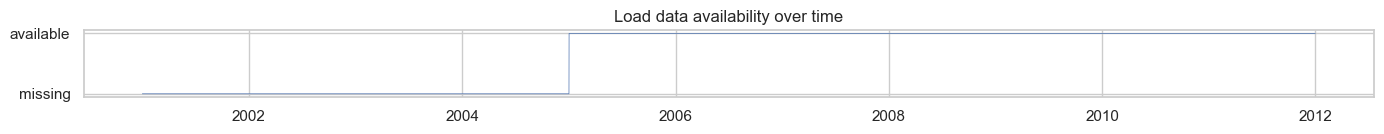

In [6]:
fig, ax = plt.subplots(figsize=(14, 1.5))
ax.plot(df.index, df["load"].notna().astype(int), lw=0.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(["missing", "available"])
ax.set_title("Load data availability over time")
plt.tight_layout()
plt.show()


## 3. The load series

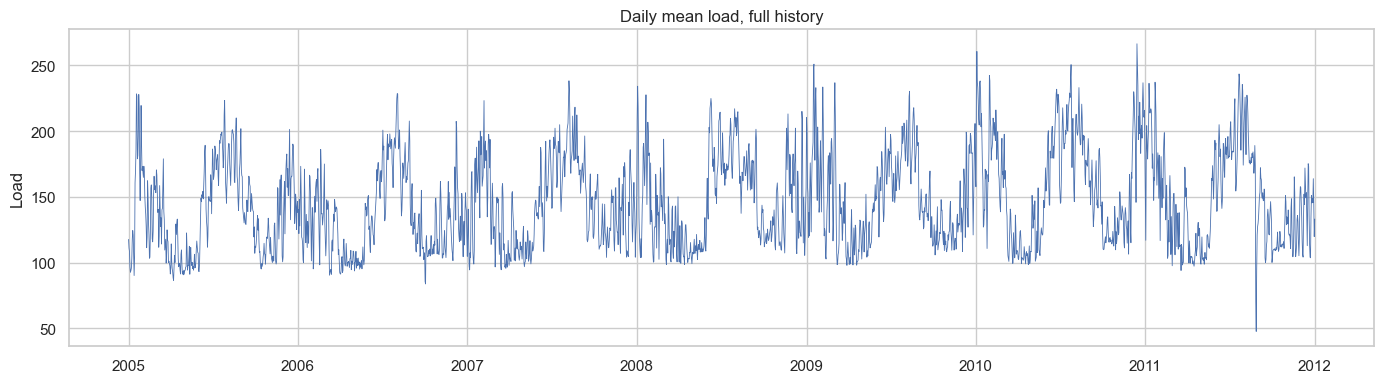

In [7]:
daily = df["load"].resample("D").mean()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, lw=0.6)
ax.set_title("Daily mean load, full history")
ax.set_ylabel("Load")
plt.tight_layout()
plt.show()


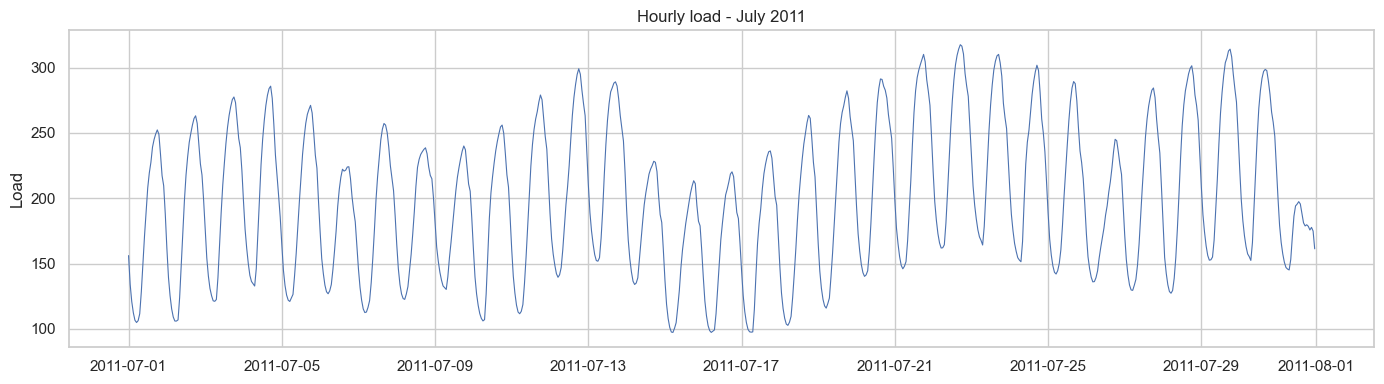

In [3]:
window = df.loc["2011-07-01":"2011-07-31", "load"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(window.index, window.values, lw=0.8)
ax.set_title("Hourly load - July 2011")
ax.set_ylabel("Load")
plt.tight_layout()
plt.show()


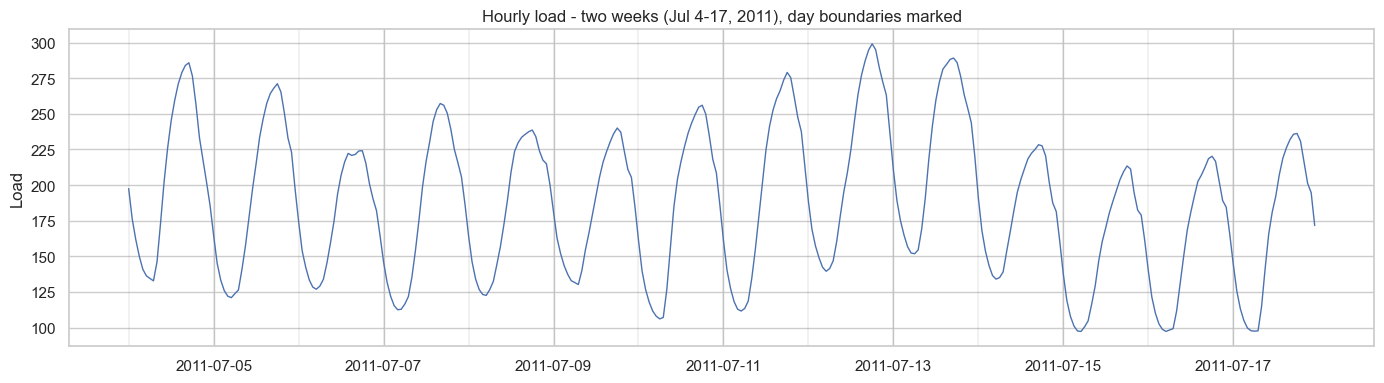

In [4]:
window = df.loc["2011-07-04":"2011-07-17", "load"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(window.index, window.values, lw=1)
for d in pd.date_range(window.index.min().normalize(), window.index.max(), freq="D"):
    ax.axvline(d, color="gray", lw=0.3, alpha=0.5)
ax.set_title("Hourly load - two weeks (Jul 4-17, 2011), day boundaries marked")
ax.set_ylabel("Load")
plt.tight_layout()
plt.show()


## 4. Seasonality

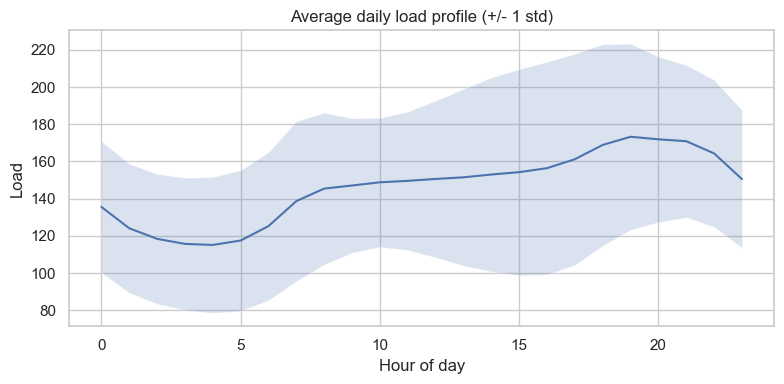

In [10]:
hourly_profile = df.groupby(df.index.hour)["load"].agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly_profile.index, hourly_profile["mean"])
ax.fill_between(hourly_profile.index,
                 hourly_profile["mean"] - hourly_profile["std"],
                 hourly_profile["mean"] + hourly_profile["std"], alpha=0.2)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Load")
ax.set_title("Average daily load profile (+/- 1 std)")
plt.tight_layout()
plt.show()


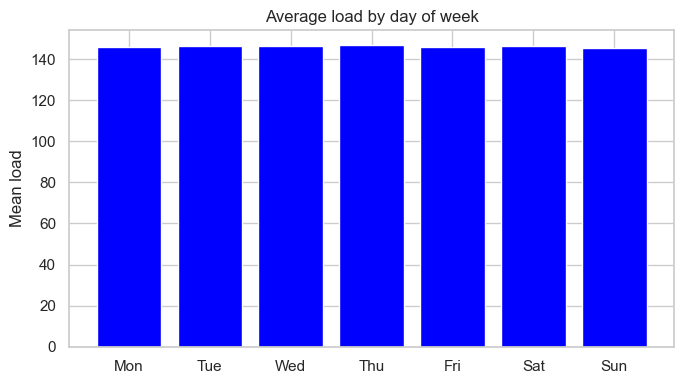

In [6]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_profile = df.groupby(df.index.dayofweek)["load"].mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dow_labels, dow_profile.values, color="blue")
ax.set_ylabel("Mean load")
ax.set_title("Average load by day of week")
plt.tight_layout()
plt.show()


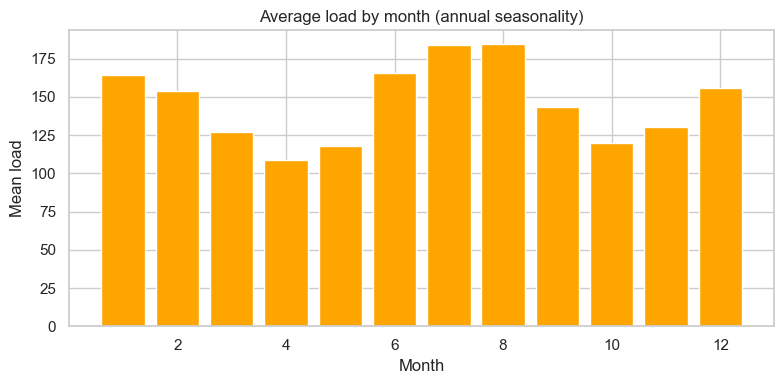

In [5]:
month_profile = df.groupby(df.index.month)["load"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(month_profile.index, month_profile.values, color="orange")
ax.set_xlabel("Month")
ax.set_ylabel("Mean load")
ax.set_title("Average load by month (annual seasonality)")
plt.tight_layout()
plt.show()


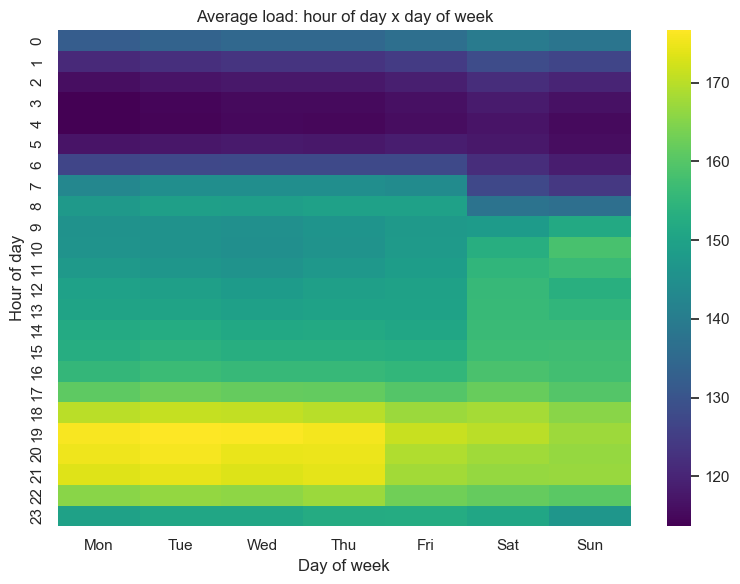

In [13]:
pivot = df.pivot_table(index=df.index.hour, columns=df.index.dayofweek, values="load", aggfunc="mean")
pivot.columns = dow_labels
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, cmap="viridis", ax=ax)
ax.set_xlabel("Day of week")
ax.set_ylabel("Hour of day")
ax.set_title("Average load: hour of day x day of week")
plt.tight_layout()
plt.show()


## 5. Distribution and outliers

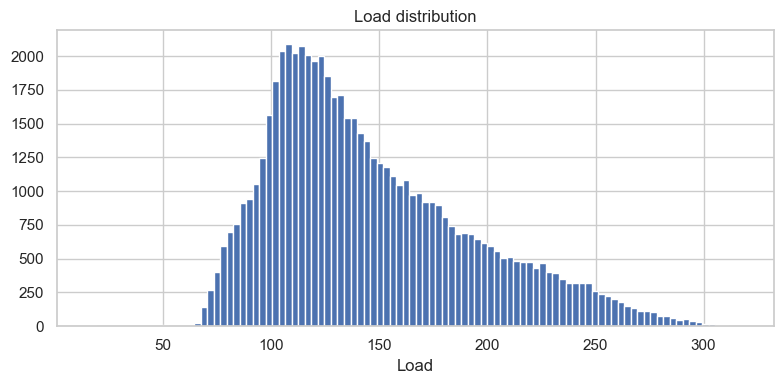

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
df["load"].hist(bins=100, ax=ax)
ax.set_title("Load distribution")
ax.set_xlabel("Load")
plt.tight_layout()
plt.show()


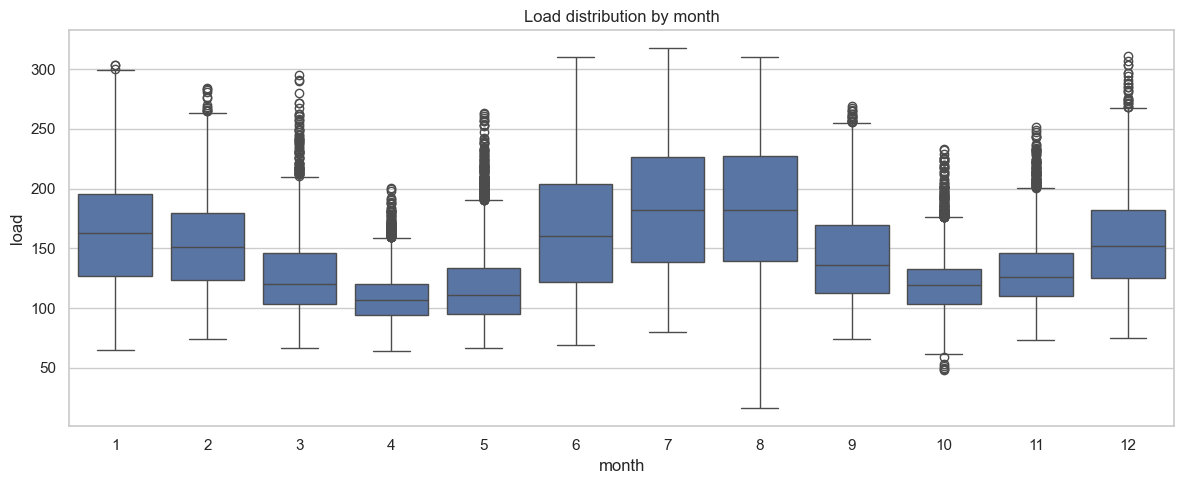

In [15]:
df_box = df.dropna(subset=["load"]).copy()
df_box["month"] = df_box.index.month
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_box, x="month", y="load", ax=ax)
ax.set_title("Load distribution by month")
plt.tight_layout()
plt.show()


In [16]:
# Flag points far from the typical hour-of-day level (crude outlier check,
# not used for cleaning -- just to see whether any values look broken).
seasonal_mean = df.groupby(df.index.hour)["load"].transform("mean")
resid = df["load"] - seasonal_mean
z = (resid - resid.mean()) / resid.std()
outliers = df.loc[z.abs() > 4, "load"].sort_values(ascending=False)
print(f"{len(outliers)} points beyond 4 std of the hour-adjusted residual")
outliers.head(10)


0 points beyond 4 std of the hour-adjusted residual


Series([], Name: load, dtype: float64)

## 6. Load vs. temperature

Electricity load is typically a U-shaped (or "hockey stick") function of
temperature: both heating (cold) and cooling (hot) demand push load up,
with a minimum around a comfortable mid-range temperature.


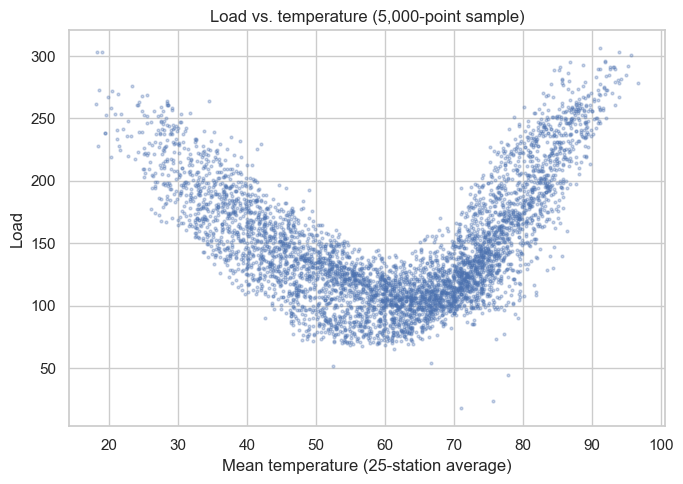

In [17]:
sample = df.dropna(subset=["load", "temp_mean"]).sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample["temp_mean"], sample["load"], s=4, alpha=0.3)
ax.set_xlabel("Mean temperature (25-station average)")
ax.set_ylabel("Load")
ax.set_title("Load vs. temperature (5,000-point sample)")
plt.tight_layout()
plt.show()


In [18]:
df[["load", "temp_mean"]].corr()


,load,temp_mean
load,1.000000,0.103335
temp_mean,0.103335,1.000000


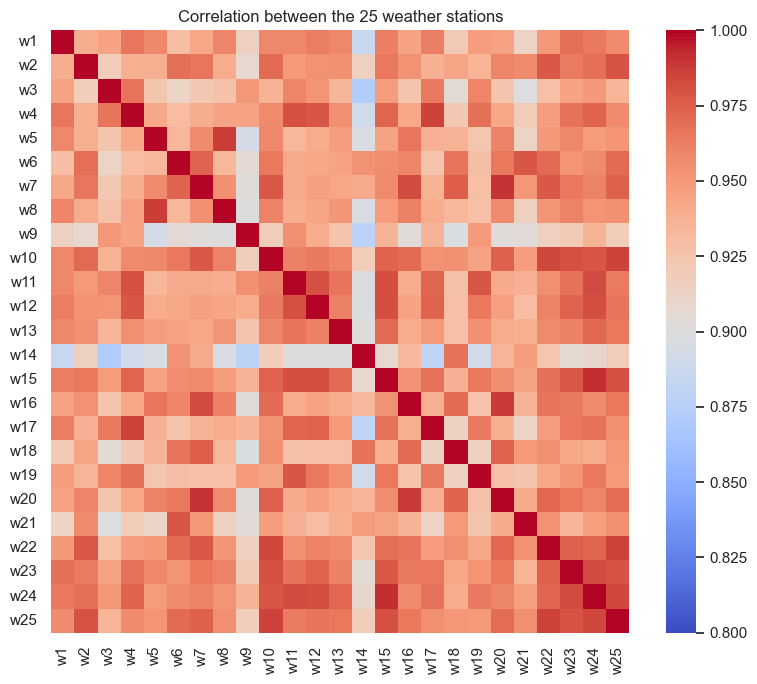

Min pairwise station correlation: 0.872


In [19]:
station_cols = [c for c in df.columns if c.startswith("w")]
corrs = df[station_cols].corr()
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corrs, cmap="coolwarm", vmin=0.8, vmax=1.0, ax=ax)
ax.set_title("Correlation between the 25 weather stations")
plt.tight_layout()
plt.show()
print(f"Min pairwise station correlation: {corrs.values[np.triu_indices_from(corrs.values, k=1)].min():.3f}")


## 7. Trend

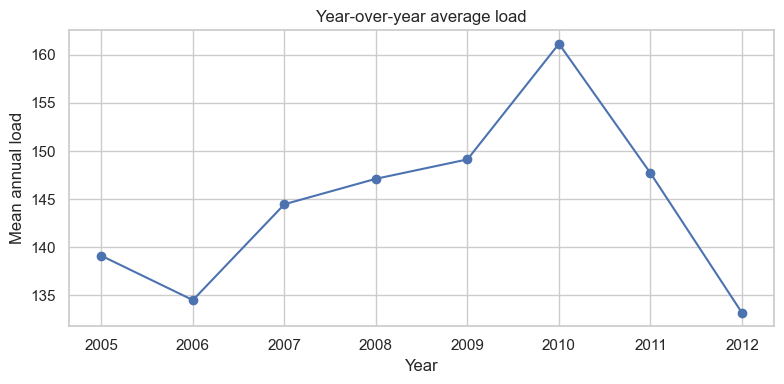

In [20]:
yearly = df.dropna(subset=["load"]).resample("YS")["load"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yearly.index.year, yearly.values, marker="o")
ax.set_xlabel("Year")
ax.set_ylabel("Mean annual load")
ax.set_title("Year-over-year average load")
plt.tight_layout()
plt.show()


## 8. Seasonal decomposition

Classical additive decomposition into trend + seasonal + residual, first at
daily resolution over the full history (annual seasonality), then at hourly
resolution over one year (weekly seasonality).


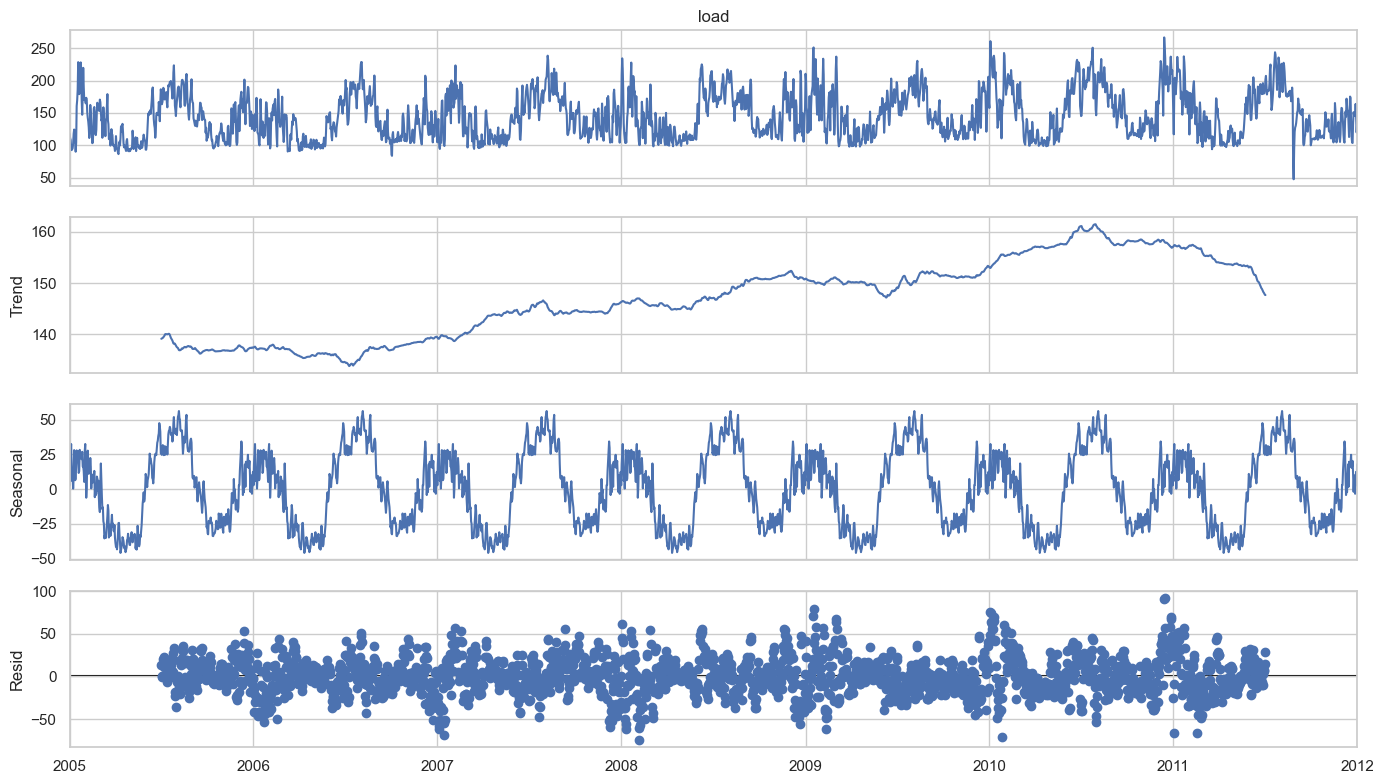

In [21]:
daily_load = df["load"].resample("D").mean().dropna()
decomposition = seasonal_decompose(daily_load, model="additive", period=365)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()


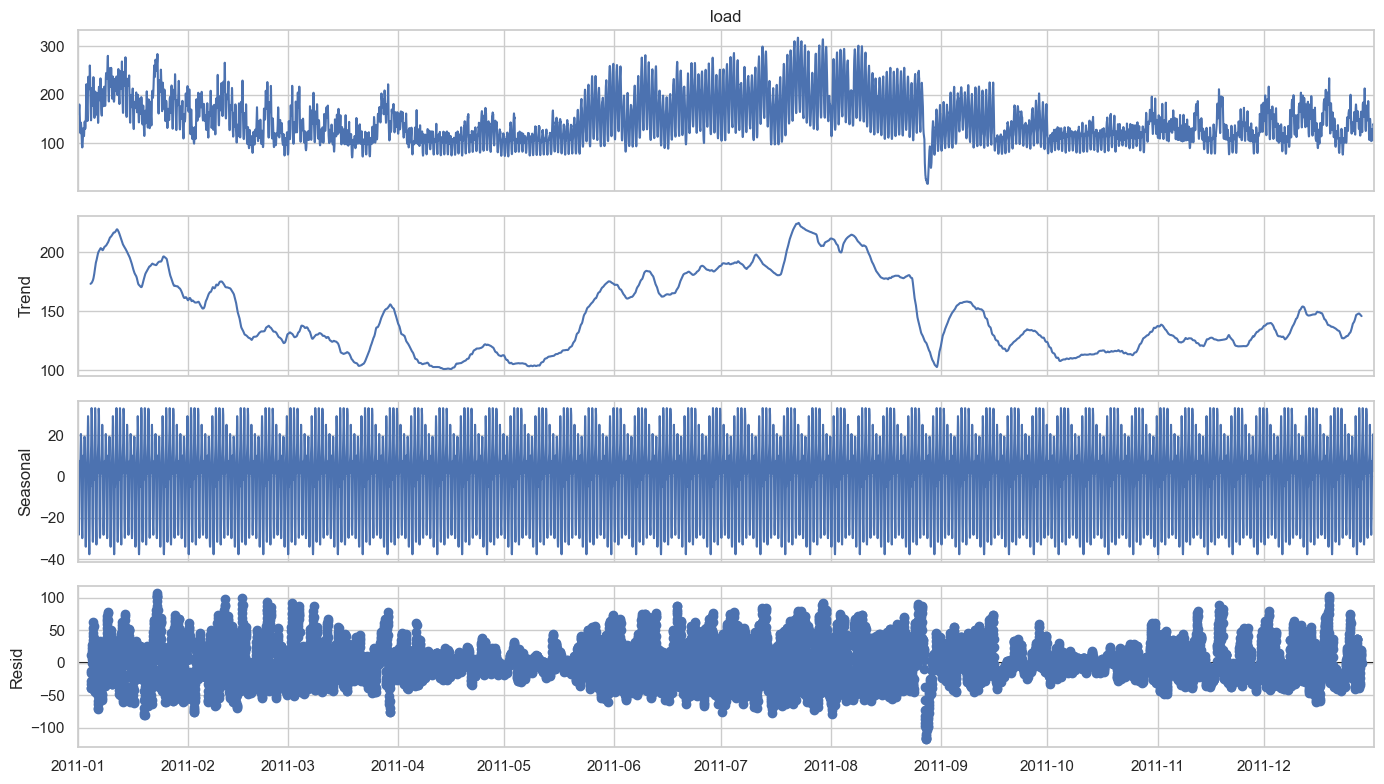

In [22]:
hourly_2011 = df.loc["2011-01-01":"2011-12-31", "load"].dropna()
decomp_hourly = seasonal_decompose(hourly_2011, model="additive", period=24 * 7)
fig = decomp_hourly.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()


## 9. Autocorrelation

Checks the daily (24h) and weekly (168h) cycles directly, and the specific
lags used as features in `configs/default.yaml`
(`load_lags_hours: [168, 336, 504, 672, 8760]`).


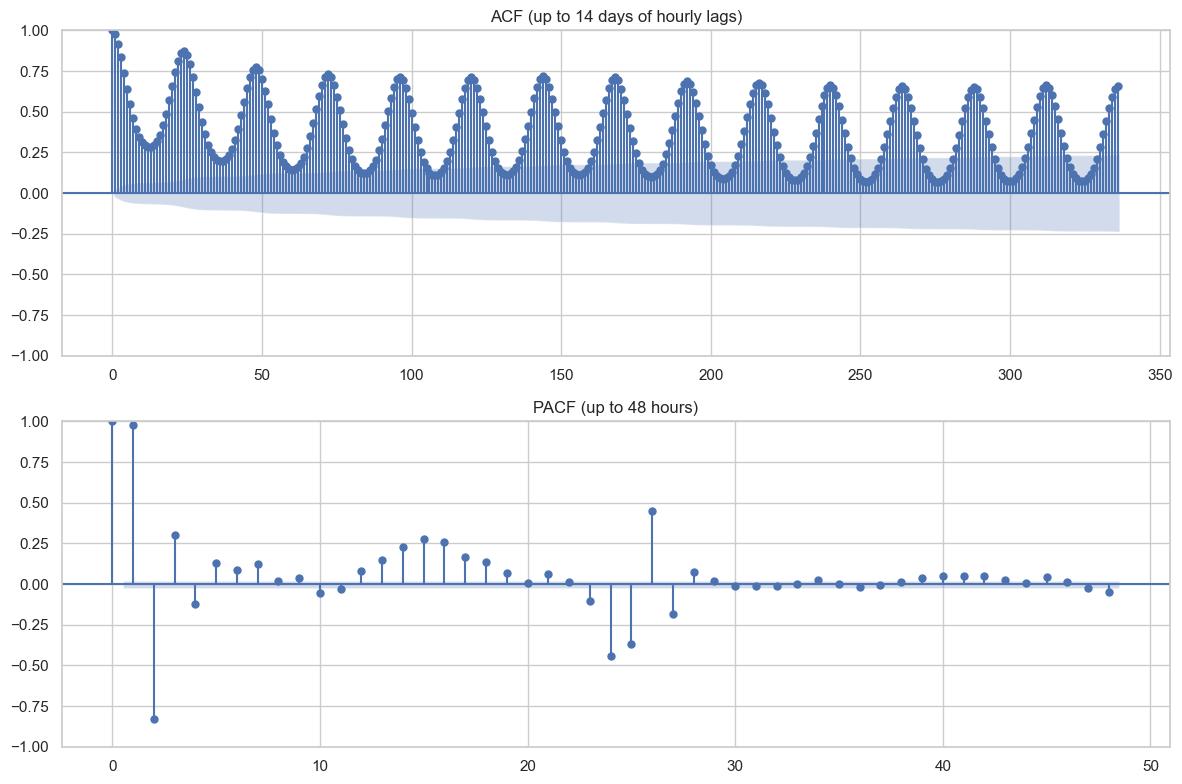

In [23]:
series = df.loc["2011-01-01":"2011-12-31", "load"].dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(series, lags=24 * 14, ax=axes[0])
axes[0].set_title("ACF (up to 14 days of hourly lags)")
plot_pacf(series, lags=48, ax=axes[1], method="ywm")
axes[1].set_title("PACF (up to 48 hours)")
plt.tight_layout()
plt.show()


In [24]:
# The 8760h (1-year) lag needs more than one year of history, so use the
# full continuous load series (2005-2012) for this check.
lags_to_check = [1, 24, 48, 168, 336, 504, 672, 8760]
full_series = df["load"].dropna()
acf_vals = acf(full_series, nlags=max(lags_to_check), fft=True)
for lag in lags_to_check:
    print(f"lag {lag:5d}h ({lag / 24:6.1f} d): acf = {acf_vals[lag]:.3f}")


lag     1h (   0.0 d): acf = 0.976
lag    24h (   1.0 d): acf = 0.878
lag    48h (   2.0 d): acf = 0.774
lag   168h (   7.0 d): acf = 0.697
lag   336h (  14.0 d): acf = 0.635
lag   504h (  21.0 d): acf = 0.582
lag   672h (  28.0 d): acf = 0.527
lag  8760h ( 365.0 d): acf = 0.558


## 10. Stationarity (Augmented Dickey-Fuller)

In [25]:
def adf_report(s, label):
    result = adfuller(s.dropna())
    verdict = "stationary" if result[1] < 0.05 else "non-stationary"
    print(f"{label:28s}: ADF stat={result[0]:8.3f}, p-value={result[1]:.4f}  ({verdict} at 5%)")

series = df["load"].dropna()
adf_report(series, "Raw load")
adf_report(series.diff(24), "24h-differenced load")
adf_report(series.diff(168), "168h (weekly)-differenced load")


Raw load                    : ADF stat= -12.570, p-value=0.0000  (stationary at 5%)


24h-differenced load        : ADF stat= -35.918, p-value=0.0000  (stationary at 5%)


168h (weekly)-differenced load: ADF stat= -22.162, p-value=0.0000  (stationary at 5%)


## 11. Rolling statistics

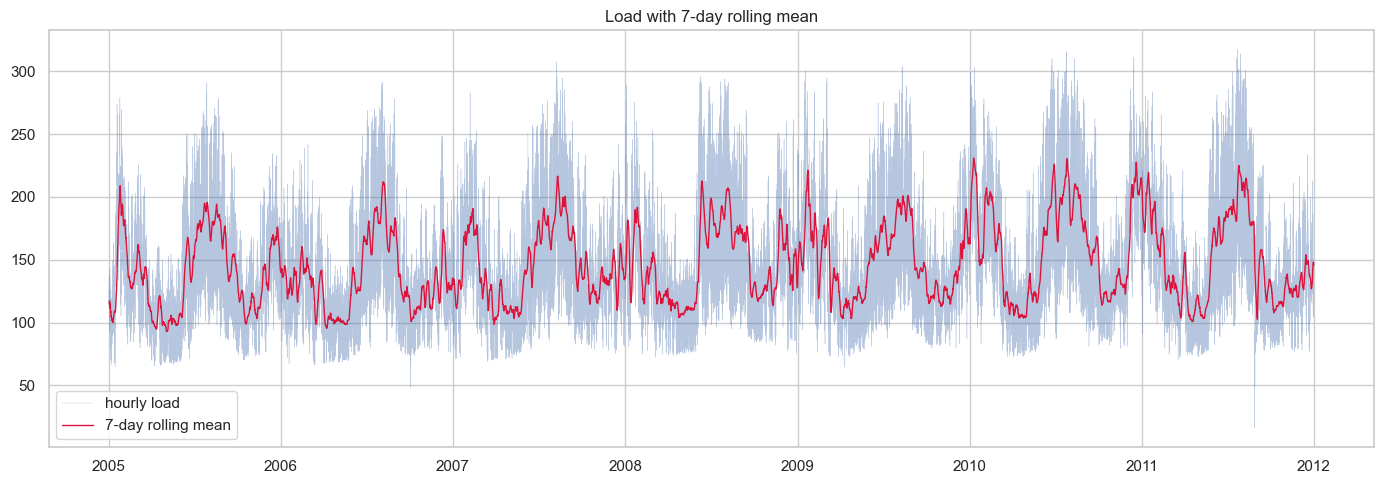

In [26]:
roll = df["load"].rolling(24 * 7, min_periods=24).mean()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["load"], lw=0.3, alpha=0.4, label="hourly load")
ax.plot(roll.index, roll.values, color="crimson", lw=1, label="7-day rolling mean")
ax.legend()
ax.set_title("Load with 7-day rolling mean")
plt.tight_layout()
plt.show()


## 12. Takeaways for modeling

- **Daily and weekly seasonality are strong** (ACF spikes at 24h, 168h,
  336h, ...) -- confirms the `load_lags_hours` / `rolling_windows_hours`
  choices in `configs/default.yaml`.
- **Load vs. temperature is U-shaped**, not linear -- a raw `temp_mean`
  feature captures direction but not the heating/cooling asymmetry; a
  squared or piecewise term helps.
- **The 25 weather stations are highly correlated** with each other, so
  averaging into `temp_mean` loses little station-specific signal.
- **2001-2004 has no load data** (weather only) -- already excluded from
  backtesting by `evaluation.create_rolling_origin_splits`, which drops
  rows with missing `load` before computing fold boundaries.
- **The raw level is non-stationary**; weekly differencing removes most of
  it -- supports using lagged/rolling features (which are effectively
  differences) rather than the raw level as model inputs.
